In [8]:
%load_ext cython

The cython extension is already loaded. To reload it, use:
  %reload_ext cython


In [13]:
# Cell 1: STRATEGIC LLM Agent - Ultra-Optimized Version
import requests
import json
import time
import re
from typing import Dict, List, Optional, Tuple

# --- CONFIGURATION ---
OLLAMA_API_URL = "http://localhost:11434/api/generate"
LLM_MODEL = "llama3:8b"

class StrategicLLMAgent:
    """LLM generates selection strategies, not direct solutions."""
    
    def __init__(self, model_name=LLM_MODEL, api_url=OLLAMA_API_URL, use_llm=True):
        self.model_name = model_name
        self.api_url = api_url
        self.use_llm = use_llm  # Can disable LLM entirely
        self.strategy_cache = {}
        print(f"🧠 Strategic LLM Agent initialized with {self.model_name}")
        if not use_llm:
            print(f"   ⚠️  LLM calls DISABLED - using fallback strategies only")
    
    def _call_ollama(self, prompt, temperature=0.3, max_tokens=150):
        """Call Ollama API with aggressive optimization."""
        payload = {
            "model": self.model_name,
            "prompt": prompt,
            "stream": False,
            "options": {
                "temperature": temperature,
                "num_predict": max_tokens,
                "top_k": 10,
                "top_p": 0.8,
                "num_ctx": 1024,  # Smaller context
                "num_thread": 8
            }
        }
        
        try:
            response = requests.post(self.api_url, json=payload, timeout=100)  # 30s timeout
            response.raise_for_status()
            return response.json()['response']
        except requests.exceptions.RequestException as e:
            print(f"⚠️  LLM API Error: {e}")
            return None
    
    def generate_initialization_strategies(self, problem_data, previous_archive_stats=None):
        """
        Generate 3 diverse initialization strategies.
        Falls back to deterministic strategies if LLM fails.
        """
        
        num_obj = problem_data['num_objectives']
        cache_key = f"{problem_data['num_items']}_{num_obj}"
        
        # Check cache
        if cache_key in self.strategy_cache:
            print(f"  -> 📦 Using cached strategies for {cache_key}")
            return self.strategy_cache[cache_key]
        
        # If LLM disabled, use fallback immediately
        if not self.use_llm:
            strategies = self._get_fallback_strategies(num_obj)
            self.strategy_cache[cache_key] = strategies
            print(f"  -> 🔧 Using {len(strategies)} fallback strategies (LLM disabled)")
            return strategies
        
        # Try LLM with simplified prompt
        prompt = self._build_simple_prompt(problem_data)
        
        print(f"  -> 🧠 Calling LLM for strategic guidance...")
        start_time = time.time()
        
        response = self._call_ollama(prompt, temperature=0.3, max_tokens=150)
        
        elapsed = time.time() - start_time
        
        if not response:
            print(f"  -> ❌ LLM failed after {elapsed:.2f}s, using fallback strategies")
            strategies = self._get_fallback_strategies(num_obj)
        else:
            strategies = self._parse_strategies(response, num_obj)
            
            if len(strategies) < 3:
                print(f"  -> ⚠️  Only got {len(strategies)} strategies, adding fallbacks")
                fallbacks = self._get_fallback_strategies(num_obj)
                strategies.extend(fallbacks[:3-len(strategies)])
            
            print(f"  -> ✅ Generated {len(strategies)} strategies in {elapsed:.2f}s")
        
        # Cache and return
        self.strategy_cache[cache_key] = strategies
        
        for i, strat in enumerate(strategies, 1):
            print(f"     {i}. {strat['name']}: {strat['description'][:60]}...")
        
        return strategies
    
    def _build_simple_prompt(self, problem_data):
        """ULTRA-SIMPLE prompt for fast response."""
        
        num_obj = problem_data['num_objectives']
        
        prompt = f"""Suggest 3 strategies for selecting items in a {num_obj}-objective knapsack.

Format:
1. Name | Description
2. Name | Description
3. Name | Description

Example:
1. Balanced | Average profit/weight ratio
2. Profit Focus | High profit1 first
3. Dense | High total profit per weight

Your 3 strategies:
"""
        return prompt
    
    def _parse_strategies(self, response, num_objectives):
        """Parse LLM response into structured strategies."""
        strategies = []
        lines = response.strip().split('\n')
        
        for line in lines:
            match = re.match(r'^\d+\.\s*(.+?)\s*[|:]\s*(.+)$', line.strip())
            if match:
                name = match.group(1).strip()
                description = match.group(2).strip()
                strategy = self._description_to_strategy(name, description, num_objectives)
                if strategy:
                    strategies.append(strategy)
        
        return strategies
    
    def _description_to_strategy(self, name, description, num_objectives):
        """Convert natural language to strategy parameters."""
        
        desc_lower = description.lower()
        
        # Detect strategy type from keywords
        if 'balance' in desc_lower or 'average' in desc_lower:
            weights = [1.0 / num_objectives] * num_objectives
            return {
                'name': name,
                'description': description,
                'type': 'weighted_ratio',
                'weights': weights,
                'threshold': 0.0
            }
        
        elif 'profit1' in desc_lower or 'first' in desc_lower or 'focus' in desc_lower:
            weights = [0.0] * num_objectives
            weights[0] = 0.7
            if num_objectives > 1:
                weights[1] = 0.3
            return {
                'name': name,
                'description': description,
                'type': 'weighted_ratio',
                'weights': weights,
                'threshold': 0.0
            }
        
        elif 'dense' in desc_lower or 'density' in desc_lower:
            return {
                'name': name,
                'description': description,
                'type': 'density',
                'weights': [1.0] * num_objectives,
                'threshold': 0.5
            }
        
        else:
            # Default: balanced
            weights = [1.0 / num_objectives] * num_objectives
            return {
                'name': name,
                'description': description,
                'type': 'weighted_ratio',
                'weights': weights,
                'threshold': 0.0
            }
    
    def _get_fallback_strategies(self, num_objectives):
        """Deterministic fallback strategies."""
        strategies = [
            {
                'name': 'Balanced',
                'description': 'Equal weight to all objectives',
                'type': 'weighted_ratio',
                'weights': [1.0/num_objectives] * num_objectives,
                'threshold': 0.0
            },
            {
                'name': 'Objective-1 Focus',
                'description': 'Prioritize first objective',
                'type': 'weighted_ratio',
                'weights': [0.7] + [0.3/(num_objectives-1)]*(num_objectives-1) if num_objectives > 1 else [1.0],
                'threshold': 0.0
            },
            {
                'name': 'High Density',
                'description': 'Select dense items (high profit per weight)',
                'type': 'density',
                'weights': [1.0] * num_objectives,
                'threshold': 0.5
            }
        ]
        return strategies


# Test with both LLM enabled and disabled
if __name__ == '__main__':
    test_problem = {
        'num_items': 250,
        'num_objectives': 2,
        'capacities': [50000, 60000]
    }
    
    print("\n" + "="*70)
    print("TEST 1: WITH LLM (if available)")
    print("="*70)
    
    agent_llm = StrategicLLMAgent(use_llm=True)
    start = time.time()
    strategies_llm = agent_llm.generate_initialization_strategies(test_problem, None)
    elapsed = time.time() - start
    
    print(f"\n✅ Test 1 completed in {elapsed:.2f}s")
    
    print("\n" + "="*70)
    print("TEST 2: WITHOUT LLM (fallback only)")
    print("="*70)
    
    agent_fallback = StrategicLLMAgent(use_llm=False)
    start = time.time()
    strategies_fallback = agent_fallback.generate_initialization_strategies(test_problem, None)
    elapsed = time.time() - start
    
    print(f"\n✅ Test 2 completed in {elapsed:.2f}s")
    
    print("\n" + "="*70)
    print("COMPARISON")
    print("="*70)
    print(f"LLM strategies: {len(strategies_llm)}")
    print(f"Fallback strategies: {len(strategies_fallback)}")


TEST 1: WITH LLM (if available)
🧠 Strategic LLM Agent initialized with llama3:8b
  -> 🧠 Calling LLM for strategic guidance...
  -> ✅ Generated 3 strategies in 40.78s
     1. **Profit-to-Weight Ratio**: Sort items by their profit-to-weight ratio and select the to...
     2. **Profit-Centric**: Select the items with the highest profit first, regardless o...
     3. **Weighted Sum**: Calculate a weighted sum for each item, where the weights ar...

✅ Test 1 completed in 40.78s

TEST 2: WITHOUT LLM (fallback only)
🧠 Strategic LLM Agent initialized with llama3:8b
   ⚠️  LLM calls DISABLED - using fallback strategies only
  -> 🔧 Using 3 fallback strategies (LLM disabled)

✅ Test 2 completed in 0.00s

COMPARISON
LLM strategies: 3
Fallback strategies: 3


In [14]:
%%cython
# Cython code for MOACP with LLM integration hooks (Stagnation Detection Strategy)
import time
from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Globals
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05
cdef int alpha = 10
cdef int paretoIni = 28000

cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0



def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind



cdef ind *ind_copy(ind *i):
    cdef ind *p_ind = create_ind(nf)
    cdef int k
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    cdef int i
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps, temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

cdef void loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

cdef void read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef int i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1


cdef void apply_strategy_init(ind *x, dict strategy):
    """Apply LLM-generated strategy to initialize solution."""
    global ni, nf, weights, profits, capacities
    
    cdef int i, j
    cdef double *item_scores = <double *>chk_malloc(ni * sizeof(double))
    cdef int *sorted_indices = <int *>chk_malloc(ni * sizeof(int))
    cdef double total_weight, total_profit, score
    
    # Calculate score for each item based on strategy
    strategy_type = strategy.get('type', 'weighted_ratio')
    strategy_weights = strategy['weights']
    
    for i in range(ni):
        if strategy_type == 'weighted_ratio':
            # Score = weighted sum of (profit/weight) ratios
            score = 0.0
            for j in range(nf):
                if weights[j][i] > 0:
                    score += strategy_weights[j] * (profits[j][i] / <double>weights[j][i])
            item_scores[i] = score
            
        elif strategy_type == 'density':
            # Score = total profit / total weight
            total_profit = 0.0
            total_weight = 0.0
            for j in range(nf):
                total_profit += strategy_weights[j] * profits[j][i]
                total_weight += weights[j][i]
            if total_weight > 0:
                item_scores[i] = total_profit / total_weight
            else:
                item_scores[i] = 0.0
        
        sorted_indices[i] = i
    
    # Sort items by score (descending) using simple bubble sort
    cdef int temp_idx
    cdef double temp_score
    for i in range(ni-1):
        for j in range(ni-1-i):
            if item_scores[sorted_indices[j]] < item_scores[sorted_indices[j+1]]:
                temp_idx = sorted_indices[j]
                sorted_indices[j] = sorted_indices[j+1]
                sorted_indices[j+1] = temp_idx
    
    # Populate x.d with sorted indices
    for i in range(ni):
        x.d[i] = sorted_indices[i]
    
    free(item_scores)
    free(sorted_indices)


cdef void strategic_init_ind(ind *x, dict strategy):
    """Initialize individual using LLM strategy instead of random."""
    apply_strategy_init(x, strategy)
            

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha, list strategies=None):
    """
    Initialize population.
    If strategies provided, use them for diversity.
    Otherwise, use archive or random.
    """
    cdef int i, x, tmp, t, strategy_idx
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(t)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    
    SP.size = alpha
    
    # If we have LLM strategies, use them for first few solutions
    if strategies is not None and len(strategies) > 0:
        strategy_count = min(len(strategies), alpha // 2)  # Use strategies for half the population
        
        for i in range(strategy_count):
            SP.ind_array[i] = create_ind(nf)
            strategic_init_ind(SP.ind_array[i], strategies[i % len(strategies)])
            evaluate(SP.ind_array[i])
        
        # Fill rest from archive or random
        for i in range(strategy_count, alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    
    else:
        # Original logic: use archive or random
        if Sarchive.size > alpha:
            for i in range(alpha):
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
        else:
            for i in range(alpha):
                if shuffle[i] < Sarchive.size:
                    SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
                else:
                    SP.ind_array[i] = create_ind(nf)
                    random_init_ind(SP.ind_array[i])
                    evaluate(SP.ind_array[i])
    
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    cdef pop *archiveAndP
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp > worst_fit:
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp - worst_fit > smallValue:
            return worst
        else:
            return -1

        

# MODIFIED FUNCTION: Indicator_local_search1 (with print statements)
cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size):
    cdef ind *x, *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    
    convergence_count = 0
    while True:
        convergence_count += 1
        #print(f"  > Archive Convergence Loop #{convergence_count}. Trying to improve population of size {SP.size}...")
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                # Start the standard local search process for solution i
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    # ... (the rest of the local search logic is unchanged)
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1



        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            #print(f"  < Archive Convergence Loop #{convergence_count} finished. No new solutions found.")
            break
        else:
            pass
            #print(f"  < Archive Convergence Loop #{convergence_count} finished. Found {convergence} new solutions.")
    free(remplace)




# MODIFIED: Enhanced run_moacp with smart LLM usage
def run_moacp(instance_file, weights_file, nbitems, num_objectives, output_file, 
              llm_agent=None):  # <-- ADD llm_agent parameter
    """
    Run MOACP with optional LLM strategic guidance.
    """
    global nf, ni, NBITEMS, alpha, paretoIni, L, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    cdef int run, it
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef int i, j
    cdef list llm_strategies
    cdef dict problem_data

    alpha = 10
    paretoIni = 28000
    NBL = 100
    NRUNS = 10

    for run in range(1, NRUNS+1):
        NBITEMS = nbitems
        ni = nbitems
        nf = num_objectives

        print(f"\n{'='*70}")
        print(f"🚀 RUN {run}/{NRUNS} | {instance_file.decode().split('.')[0]}")
        if llm_agent:
            print(f"   🧠 LLM Strategic Guidance: ENABLED")
        else:
            print(f"   🔧 LLM Strategic Guidance: DISABLED (Baseline)")
        print(f"{'='*70}")

        nombreLIGNE = 0
        nextLn = 0
        inv = 0

        seed(run)
        loadMOKP(instance_file)
        read_weights_file(weights_file)

        vector_weight = <double *>chk_malloc(nf * sizeof(double))
        P = create_pop(paretoIni, nf)

        # 🔥 ONE LLM CALL PER RUN (if agent provided)
        llm_strategies = None
        if llm_agent is not None:
            problem_data = {
                'num_items': ni,
                'num_objectives': nf,
                'capacities': [capacities[j] for j in range(nf)]
            }
            
            # Optional: provide previous run stats
            previous_stats = None
            if run > 1:
                previous_stats = {
                    'avg_pareto_size': P.size,
                }
            
            print(f"\n🧠 Generating strategic guidance (ONE LLM call)...")
            import time
            llm_start = time.time()
            llm_strategies = llm_agent.generate_initialization_strategies(
                problem_data, previous_stats
            )
            llm_time = time.time() - llm_start
            print(f"   ✅ Strategies generated in {llm_time:.2f}s")

        # Main optimization loop
        it = 0
        while it < NBL:
            progress = (it + 1) / NBL
            if progress in [0.25, 0.5, 0.75, 1.0]:
                print(f"[{progress*100:3.0f}%] Iter {it+1:3d}/{NBL} | Archive: {P.size:4d}")
            
            solutions = create_pop(alpha, nf)
            archive = create_pop(paretoIni, nf)
            choose_weight()
            
            # 🔥 USE STRATEGIES IN INITIALIZATION
            P_init_pop(solutions, P, alpha, llm_strategies)
            
            extractPtoArchive(solutions, P)
            calcul_weight(solutions, alpha)
            calcMaxbound(solutions, alpha)
            compute_all_fitness(solutions)
            Indicator_local_search1(solutions, archive, alpha)
            extractPtoArchive(archive, P)
            
            it += 1
            complete_free_pop(solutions)
            complete_free_pop(archive)

        print(f"\n✅ Run {run} Complete | Archive: {P.size:4d}")
        
        # Write results
        with open(output_file, "a") as fpareto:
            fpareto.write("\n")
            for i in range(P.size):
                for j in range(nf):
                    fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
                fpareto.write("\n")

        complete_free_pop(P)
        cleanup_globals()


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
   STRATEGIC LLM OPTIMIZATION EXPERIMENT v3.0
🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀

🔧 EXPERIMENT 1: BASELINE (No LLM)

🚀 RUN 1/10 | 250
   🔧 LLM Strategic Guidance: DISABLED (Baseline)
[ 25%] Iter  25/100 | Archive:   82
[ 50%] Iter  50/100 | Archive:  127
[ 75%] Iter  75/100 | Archive:  128
[100%] Iter 100/100 | Archive:  132

✅ Run 1 Complete | Archive:  130

🚀 RUN 2/10 | 250
   🔧 LLM Strategic Guidance: DISABLED (Baseline)
[ 25%] Iter  25/100 | Archive:   15
[ 50%] Iter  50/100 | Archive:   47
[ 75%] Iter  75/100 | Archive:  117
[100%] Iter 100/100 | Archive:  120

✅ Run 2 Complete | Archive:  120

🚀 RUN 3/10 | 250
   🔧 LLM Strategic Guidance: DISABLED (Baseline)
[ 25%] Iter  25/100 | Archive:   56
[ 50%] Iter  50/100 | Archive:  106
[ 75%] Iter  75/100 | Archive:  125
[100%] Iter 100/100 | Archive:  116

✅ Run 3 Complete | Archive:  116

🚀 RUN 4/10 | 250
   🔧 LLM Strategic Guidance: DISABLED (Baseline)
[ 25%] Iter  25/100 | Archive:   88
[ 50%] Iter  50/10

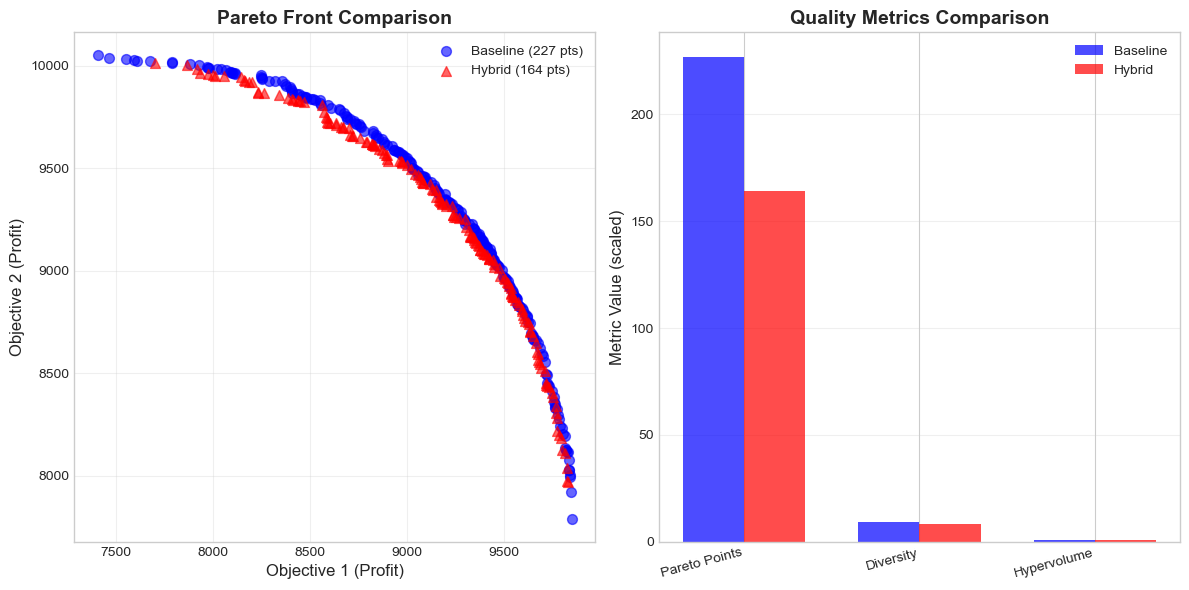

In [15]:
# Cell 3: Streamlined Strategic Experiment Controller

import os
import time
import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume_2d(pareto_front, reference_point):
    """Calculate hypervolume for 2D problems (approximation)."""
    if len(pareto_front) == 0:
        return 0.0
    
    # Sort by first objective (descending)
    sorted_front = sorted(pareto_front, key=lambda x: x[0], reverse=True)
    
    hypervolume = 0.0
    for i in range(len(sorted_front)):
        if i == len(sorted_front) - 1:
            width = sorted_front[i][0] - reference_point[0]
        else:
            width = sorted_front[i][0] - sorted_front[i+1][0]
        
        height = sorted_front[i][1] - reference_point[1]
        
        if width > 0 and height > 0:
            hypervolume += width * height
    
    return hypervolume

def analyze_pareto_quality(filename, reference_point=None):
    """Comprehensive Pareto front analysis."""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        points.append([float(x) for x in line.split()])
                    except Exception:
                        pass
    except FileNotFoundError:
        return None
    
    if len(points) == 0:
        return None
    
    pareto_front = get_true_pareto_front(points)
    
    # Calculate metrics
    metrics = {
        'total_points': len(points),
        'pareto_points': len(pareto_front),
        'pareto_ratio': len(pareto_front) / len(points) if points else 0,
    }
    
    # Diversity (average distance between Pareto points)
    if len(pareto_front) > 1:
        distances = []
        for i in range(len(pareto_front)):
            for j in range(i+1, len(pareto_front)):
                dist = sum((a-b)**2 for a, b in zip(pareto_front[i], pareto_front[j]))
                distances.append(dist**0.5)
        metrics['diversity'] = sum(distances) / len(distances)
    else:
        metrics['diversity'] = 0.0
    
    # Hypervolume (for 2D)
    if len(pareto_front) > 0 and len(pareto_front[0]) == 2:
        if reference_point is None:
            # Auto-detect reference point (slightly below minimum)
            min_obj1 = min(p[0] for p in pareto_front)
            min_obj2 = min(p[1] for p in pareto_front)
            reference_point = [min_obj1 * 0.9, min_obj2 * 0.9]
        
        metrics['hypervolume'] = calculate_hypervolume_2d(pareto_front, reference_point)
        metrics['reference_point'] = reference_point
    else:
        metrics['hypervolume'] = 0.0
    
    # Objective ranges
    if len(pareto_front) > 0:
        num_obj = len(pareto_front[0])
        metrics['objective_ranges'] = []
        for obj_idx in range(num_obj):
            obj_values = [p[obj_idx] for p in pareto_front]
            metrics['objective_ranges'].append({
                'min': min(obj_values),
                'max': max(obj_values),
                'range': max(obj_values) - min(obj_values)
            })
    
    metrics['pareto_front'] = pareto_front
    
    return metrics

def plot_comparison(baseline_file, hybrid_file, output_plot='comparison.png'):
    """Plot Pareto fronts comparison."""
    baseline_metrics = analyze_pareto_quality(baseline_file)
    hybrid_metrics = analyze_pareto_quality(hybrid_file)
    
    if not baseline_metrics or not hybrid_metrics:
        print("⚠️  Cannot plot: missing data")
        return
    
    baseline_pf = baseline_metrics['pareto_front']
    hybrid_pf = hybrid_metrics['pareto_front']
    
    if len(baseline_pf[0]) != 2:
        print("⚠️  Plotting only available for 2-objective problems")
        return
    
    plt.figure(figsize=(12, 6))
    
    # Plot 1: Overlay
    plt.subplot(1, 2, 1)
    b_x, b_y = zip(*baseline_pf)
    h_x, h_y = zip(*hybrid_pf)
    
    plt.scatter(b_x, b_y, alpha=0.6, s=50, c='blue', label=f'Baseline ({len(baseline_pf)} pts)', marker='o')
    plt.scatter(h_x, h_y, alpha=0.6, s=50, c='red', label=f'Hybrid ({len(hybrid_pf)} pts)', marker='^')
    plt.xlabel('Objective 1 (Profit)', fontsize=12)
    plt.ylabel('Objective 2 (Profit)', fontsize=12)
    plt.title('Pareto Front Comparison', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Metrics comparison
    plt.subplot(1, 2, 2)
    metrics_names = ['Pareto Points', 'Diversity', 'Hypervolume']
    baseline_vals = [
        baseline_metrics['pareto_points'],
        baseline_metrics['diversity'] / 100,  # Scale for visibility
        baseline_metrics['hypervolume'] / 1e7  # Scale for visibility
    ]
    hybrid_vals = [
        hybrid_metrics['pareto_points'],
        hybrid_metrics['diversity'] / 100,
        hybrid_metrics['hypervolume'] / 1e7
    ]
    
    x = np.arange(len(metrics_names))
    width = 0.35
    
    plt.bar(x - width/2, baseline_vals, width, label='Baseline', color='blue', alpha=0.7)
    plt.bar(x + width/2, hybrid_vals, width, label='Hybrid', color='red', alpha=0.7)
    
    plt.ylabel('Metric Value (scaled)', fontsize=12)
    plt.title('Quality Metrics Comparison', fontsize=14, fontweight='bold')
    plt.xticks(x, metrics_names, rotation=15, ha='right')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(output_plot, dpi=300, bbox_inches='tight')
    print(f"📊 Plot saved to {output_plot}")
    plt.show()


# Configuration
INSTANCE_FILE = b"250.2.txt"
WEIGHTS_FILE = b"Weights_2obj_FQ200.txt"
NB_ITEMS = 250
NUM_OBJECTIVES = 2
OUTPUT_BASELINE = "250_2obj_BASELINE_strategic.txt"
OUTPUT_HYBRID = "250_2obj_HYBRID_strategic.txt"

def run_strategic_experiment():
    """Run baseline vs strategic LLM experiment."""
    
    print("\n" + "🚀"*30)
    print("   STRATEGIC LLM OPTIMIZATION EXPERIMENT v3.0")
    print("🚀"*30)
    
    # Clean up
    for file in [OUTPUT_BASELINE, OUTPUT_HYBRID]:
        if os.path.exists(file):
            os.remove(file)
    
    # Experiment 1: Baseline (No LLM)
    print("\n" + "="*70)
    print("🔧 EXPERIMENT 1: BASELINE (No LLM)")
    print("="*70)
    
    start_baseline = time.time()
    run_moacp(INSTANCE_FILE, WEIGHTS_FILE, NB_ITEMS, NUM_OBJECTIVES, 
              OUTPUT_BASELINE, llm_agent=None)
    time_baseline = time.time() - start_baseline
    
    # Experiment 2: Strategic LLM
    print("\n" + "="*70)
    print("🧠 EXPERIMENT 2: STRATEGIC LLM")
    print("="*70)
    
    agent = StrategicLLMAgent()
    start_hybrid = time.time()
    run_moacp(INSTANCE_FILE, WEIGHTS_FILE, NB_ITEMS, NUM_OBJECTIVES, 
              OUTPUT_HYBRID, llm_agent=agent)
    time_hybrid = time.time() - start_hybrid
    
    # Analysis
    print("\n" + "="*70)
    print("📊 COMPREHENSIVE RESULTS ANALYSIS")
    print("="*70)
    
    baseline_metrics = analyze_pareto_quality(OUTPUT_BASELINE)
    hybrid_metrics = analyze_pareto_quality(OUTPUT_HYBRID)
    
    if not baseline_metrics or not hybrid_metrics:
        print("❌ Analysis failed - missing result files")
        return
    
    # Print comparison table
    print(f"\n{'Metric':<25} | {'Baseline':<15} | {'Hybrid':<15} | {'Improvement':<15}")
    print("-" * 75)
    
    # Pareto points
    b_pareto = baseline_metrics['pareto_points']
    h_pareto = hybrid_metrics['pareto_points']
    improvement = ((h_pareto - b_pareto) / b_pareto * 100) if b_pareto > 0 else 0
    print(f"{'Pareto Points':<25} | {b_pareto:<15} | {h_pareto:<15} | {improvement:+.2f}%")
    
    # Diversity
    b_div = baseline_metrics['diversity']
    h_div = hybrid_metrics['diversity']
    div_improvement = ((h_div - b_div) / b_div * 100) if b_div > 0 else 0
    print(f"{'Diversity':<25} | {b_div:<15.2f} | {h_div:<15.2f} | {div_improvement:+.2f}%")
    
    # Hypervolume
    b_hv = baseline_metrics['hypervolume']
    h_hv = hybrid_metrics['hypervolume']
    hv_improvement = ((h_hv - b_hv) / b_hv * 100) if b_hv > 0 else 0
    print(f"{'Hypervolume':<25} | {b_hv:<15.2e} | {h_hv:<15.2e} | {hv_improvement:+.2f}%")
    
    # Runtime
    print("\n" + "-" * 75)
    print(f"{'Runtime (seconds)':<25} | {time_baseline:<15.2f} | {time_hybrid:<15.2f} | {time_hybrid-time_baseline:+.2f}s")
    overhead_pct = ((time_hybrid - time_baseline) / time_baseline * 100) if time_baseline > 0 else 0
    print(f"{'Overhead':<25} | {'0%':<15} | {overhead_pct:<15.2f}% | {overhead_pct:+.2f}%")
    
    # Determine winner
    print("\n" + "="*70)
    
    # Score calculation (weighted)
    score_baseline = 0
    score_hybrid = 0
    
    # Hypervolume is most important (weight: 3)
    if h_hv > b_hv * 1.02:  # At least 2% improvement
        score_hybrid += 3
    elif b_hv > h_hv * 1.02:
        score_baseline += 3
    
    # Pareto points (weight: 2)
    if h_pareto > b_pareto:
        score_hybrid += 2
    elif b_pareto > h_pareto:
        score_baseline += 2
    
    # Diversity (weight: 1)
    if h_div > b_div:
        score_hybrid += 1
    elif b_div > h_div:
        score_baseline += 1
    
    # Runtime penalty if >20% slower
    if overhead_pct > 20:
        score_baseline += 1
    
    if score_hybrid > score_baseline:
        print("🏆 WINNER: STRATEGIC LLM HYBRID")
        print(f"   📈 Quality Score: {score_hybrid} vs {score_baseline}")
        print(f"   🎯 Hypervolume Improvement: {hv_improvement:+.2f}%")
        print(f"   ⏱️  Runtime Overhead: {overhead_pct:.1f}%")
    elif score_baseline > score_hybrid:
        print("🏆 WINNER: BASELINE")
        print(f"   📈 Quality Score: {score_baseline} vs {score_hybrid}")
        print(f"   💡 Recommendation: Refine LLM strategies or prompt engineering")
    else:
        print("🤝 RESULT: TIE")
        print(f"   ⚖️  Both approaches achieved similar quality")
        print(f"   💭 Consider: LLM adds {overhead_pct:.1f}% overhead for {hv_improvement:+.2f}% HV improvement")
    
    print("="*70)
    
    # Generate plot
    plot_comparison(OUTPUT_BASELINE, OUTPUT_HYBRID, 'strategic_comparison.png')
    
    return {
        'baseline_time': time_baseline,
        'hybrid_time': time_hybrid,
        'baseline_metrics': baseline_metrics,
        'hybrid_metrics': hybrid_metrics,
        'hypervolume_improvement': hv_improvement,
        'overhead_pct': overhead_pct
    }

# Execute
if __name__ == "__main__":
    results = run_strategic_experiment()

VISUALIZING PARETO FRONTS


C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:175: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
C:\Users\Aziz il patal\AppData\Local\Temp\ipykernel_5860\2811596463.py:176: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('pareto_comparison.png', dpi=300, bbox_inches='tight')
C:\Users\Aziz il patal\AppData\L

✅ Plot saved as 'pareto_comparison.png'


A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
A:\conda\envs\ibmols\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


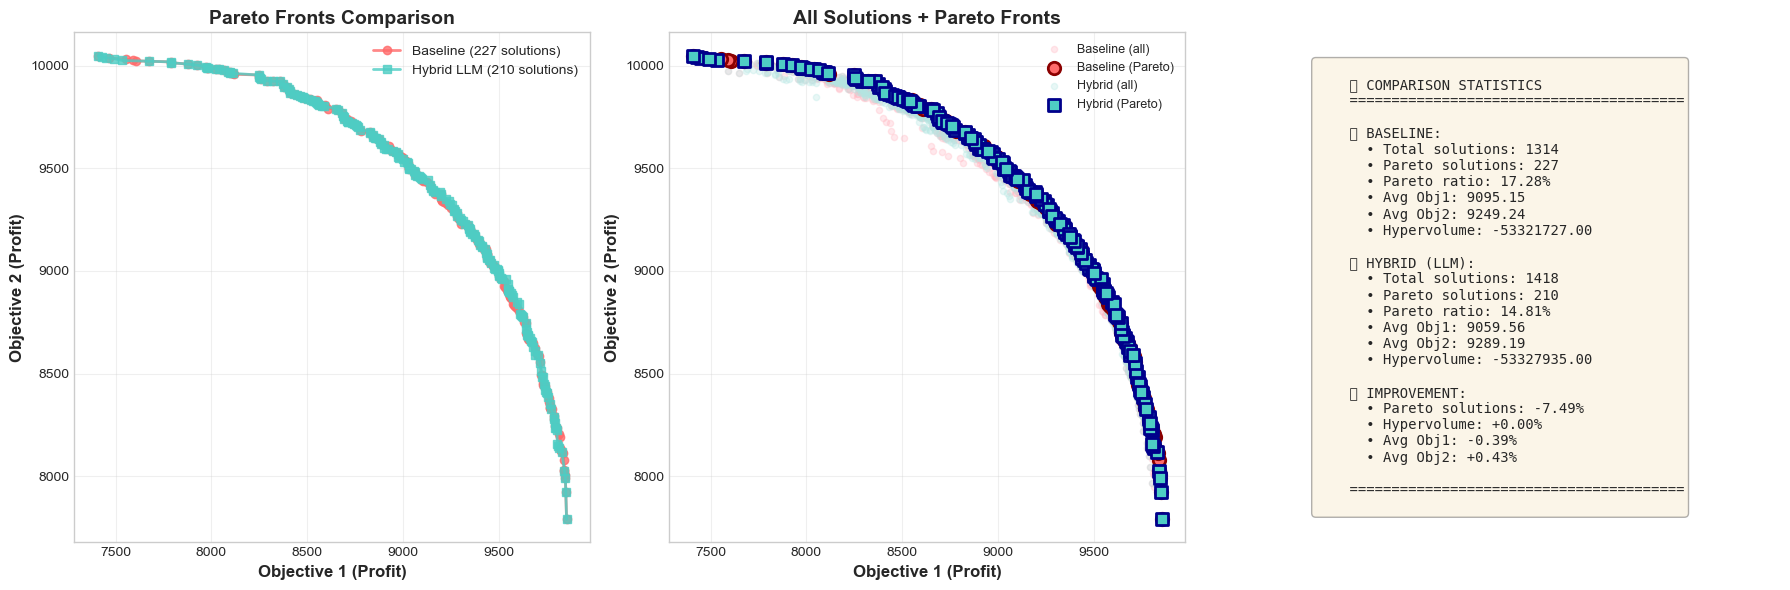


📊 QUICK SUMMARY:
Baseline Pareto: 227 solutions
Hybrid Pareto:   210 solutions
Improvement:     -7.49%
Hypervolume imp: +0.00%



In [13]:
# Cell: Visualization - Pareto Front Comparison

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

def load_points_from_file(filename):
    """Load all points from results file"""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        points.append([float(x) for x in line.split()])
                    except:
                        pass
    except FileNotFoundError:
        print(f"❌ File not found: {filename}")
        return []
    return points

def dominates(a, b):
    """Check if solution a dominates b (maximization)"""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_pareto_front(points):
    """Extract Pareto-optimal solutions"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume_2d(pareto_front, reference_point):
    """Calculate hypervolume for 2D (approximation)"""
    if len(pareto_front) == 0:
        return 0.0
    
    # Sort by first objective (descending)
    sorted_front = sorted(pareto_front, key=lambda x: x[0], reverse=True)
    
    hypervolume = 0.0
    prev_f1 = reference_point[0]
    
    for solution in sorted_front:
        f1, f2 = solution[0], solution[1]
        width = prev_f1 - f1
        height = f2 - reference_point[1]
        hypervolume += width * height
        prev_f1 = f1
    
    return hypervolume

def plot_pareto_comparison_2d(baseline_file, hybrid_file, title="Pareto Front Comparison"):
    """Plot 2D Pareto front comparison"""
    
    # Load data
    baseline_points = load_points_from_file(baseline_file)
    hybrid_points = load_points_from_file(hybrid_file)
    
    if not baseline_points or not hybrid_points:
        print("❌ Cannot load data files")
        return
    
    # Extract Pareto fronts
    baseline_pareto = get_pareto_front(baseline_points)
    hybrid_pareto = get_pareto_front(hybrid_points)
    
    # Convert to numpy arrays
    baseline_pareto = np.array(baseline_pareto)
    hybrid_pareto = np.array(hybrid_pareto)
    baseline_all = np.array(baseline_points)
    hybrid_all = np.array(hybrid_points)
    
    # Create figure with subplots
    fig = plt.figure(figsize=(18, 6))
    
    # ========== SUBPLOT 1: Pareto Fronts Only ==========
    ax1 = fig.add_subplot(1, 3, 1)
    
    # Sort for line plotting
    baseline_sorted = baseline_pareto[baseline_pareto[:, 0].argsort()]
    hybrid_sorted = hybrid_pareto[hybrid_pareto[:, 0].argsort()]
    
    ax1.plot(baseline_sorted[:, 0], baseline_sorted[:, 1], 
             'o-', color='#FF6B6B', linewidth=2, markersize=6, 
             label=f'Baseline ({len(baseline_pareto)} solutions)', alpha=0.8)
    ax1.plot(hybrid_sorted[:, 0], hybrid_sorted[:, 1], 
             's-', color='#4ECDC4', linewidth=2, markersize=6, 
             label=f'Hybrid LLM ({len(hybrid_pareto)} solutions)', alpha=0.8)
    
    ax1.set_xlabel('Objective 1 (Profit)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Objective 2 (Profit)', fontsize=12, fontweight='bold')
    ax1.set_title('Pareto Fronts Comparison', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # ========== SUBPLOT 2: All Solutions ==========
    ax2 = fig.add_subplot(1, 3, 2)
    
    ax2.scatter(baseline_all[:, 0], baseline_all[:, 1], 
                c='#FFB6C1', s=20, alpha=0.3, label='Baseline (all)')
    ax2.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1], 
                c='#FF6B6B', s=80, marker='o', edgecolors='darkred', 
                linewidths=2, label='Baseline (Pareto)', zorder=5)
    
    ax2.scatter(hybrid_all[:, 0], hybrid_all[:, 1], 
                c='#B4E7E3', s=20, alpha=0.3, label='Hybrid (all)')
    ax2.scatter(hybrid_pareto[:, 0], hybrid_pareto[:, 1], 
                c='#4ECDC4', s=80, marker='s', edgecolors='darkblue', 
                linewidths=2, label='Hybrid (Pareto)', zorder=5)
    
    ax2.set_xlabel('Objective 1 (Profit)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Objective 2 (Profit)', fontsize=12, fontweight='bold')
    ax2.set_title('All Solutions + Pareto Fronts', fontsize=14, fontweight='bold')
    ax2.legend(loc='best', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    # ========== SUBPLOT 3: Statistics ==========
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axis('off')
    
    # Calculate metrics
    ref_point = [0, 0]  # For hypervolume (nadir point)
    hv_baseline = calculate_hypervolume_2d(baseline_pareto.tolist(), ref_point)
    hv_hybrid = calculate_hypervolume_2d(hybrid_pareto.tolist(), ref_point)
    hv_improvement = ((hv_hybrid - hv_baseline) / hv_baseline * 100) if hv_baseline > 0 else 0
    
    pareto_improvement = ((len(hybrid_pareto) - len(baseline_pareto)) / len(baseline_pareto) * 100)
    
    # Average objectives
    baseline_avg = baseline_pareto.mean(axis=0)
    hybrid_avg = hybrid_pareto.mean(axis=0)
    
    stats_text = f"""
    📊 COMPARISON STATISTICS
    {'='*40}
    
    🔴 BASELINE:
      • Total solutions: {len(baseline_points)}
      • Pareto solutions: {len(baseline_pareto)}
      • Pareto ratio: {len(baseline_pareto)/len(baseline_points)*100:.2f}%
      • Avg Obj1: {baseline_avg[0]:.2f}
      • Avg Obj2: {baseline_avg[1]:.2f}
      • Hypervolume: {hv_baseline:.2f}
    
    🔵 HYBRID (LLM):
      • Total solutions: {len(hybrid_points)}
      • Pareto solutions: {len(hybrid_pareto)}
      • Pareto ratio: {len(hybrid_pareto)/len(hybrid_points)*100:.2f}%
      • Avg Obj1: {hybrid_avg[0]:.2f}
      • Avg Obj2: {hybrid_avg[1]:.2f}
      • Hypervolume: {hv_hybrid:.2f}
    
    📈 IMPROVEMENT:
      • Pareto solutions: {pareto_improvement:+.2f}%
      • Hypervolume: {hv_improvement:+.2f}%
      • Avg Obj1: {(hybrid_avg[0]-baseline_avg[0])/baseline_avg[0]*100:+.2f}%
      • Avg Obj2: {(hybrid_avg[1]-baseline_avg[1])/baseline_avg[1]*100:+.2f}%
    
    {'='*40}
    """
    
    ax3.text(0.1, 0.5, stats_text, fontsize=10, family='monospace',
             verticalalignment='center', bbox=dict(boxstyle='round', 
             facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.savefig('pareto_comparison.png', dpi=300, bbox_inches='tight')
    print("✅ Plot saved as 'pareto_comparison.png'")
    plt.show()
    
    # Return metrics for further analysis
    return {
        'baseline': {
            'total': len(baseline_points),
            'pareto': len(baseline_pareto),
            'hypervolume': hv_baseline,
            'avg': baseline_avg
        },
        'hybrid': {
            'total': len(hybrid_points),
            'pareto': len(hybrid_pareto),
            'hypervolume': hv_hybrid,
            'avg': hybrid_avg
        },
        'improvement': {
            'pareto_pct': pareto_improvement,
            'hypervolume_pct': hv_improvement
        }
    }


def plot_pareto_comparison_3d(baseline_file, hybrid_file):
    """Plot 3D Pareto front comparison (for 3-objective problems)"""
    
    baseline_points = load_points_from_file(baseline_file)
    hybrid_points = load_points_from_file(hybrid_file)
    
    if not baseline_points or not hybrid_points:
        print("❌ Cannot load data files")
        return
    
    if len(baseline_points[0]) != 3:
        print("⚠️  This function is for 3-objective problems only")
        return
    
    baseline_pareto = np.array(get_pareto_front(baseline_points))
    hybrid_pareto = np.array(get_pareto_front(hybrid_points))
    
    fig = plt.figure(figsize=(14, 6))
    
    # Subplot 1: Baseline
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.scatter(baseline_pareto[:, 0], baseline_pareto[:, 1], baseline_pareto[:, 2],
                c='#FF6B6B', s=50, alpha=0.6, edgecolors='darkred', linewidths=1.5)
    ax1.set_xlabel('Objective 1', fontweight='bold')
    ax1.set_ylabel('Objective 2', fontweight='bold')
    ax1.set_zlabel('Objective 3', fontweight='bold')
    ax1.set_title(f'Baseline Pareto Front\n({len(baseline_pareto)} solutions)', fontweight='bold')
    
    # Subplot 2: Hybrid
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.scatter(hybrid_pareto[:, 0], hybrid_pareto[:, 1], hybrid_pareto[:, 2],
                c='#4ECDC4', s=50, alpha=0.6, edgecolors='darkblue', linewidths=1.5)
    ax2.set_xlabel('Objective 1', fontweight='bold')
    ax2.set_ylabel('Objective 2', fontweight='bold')
    ax2.set_zlabel('Objective 3', fontweight='bold')
    ax2.set_title(f'Hybrid LLM Pareto Front\n({len(hybrid_pareto)} solutions)', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('pareto_comparison_3d.png', dpi=300, bbox_inches='tight')
    print("✅ 3D plot saved as 'pareto_comparison_3d.png'")
    plt.show()


# ========== USAGE EXAMPLES ==========

if __name__ == "__main__":
    print("VISUALIZING PARETO FRONTS")
    
    # For 2-objective problems
    metrics = plot_pareto_comparison_2d(
        OUTPUT_BASELINE, 
        OUTPUT_HYBRID,
        title="Baseline vs Hybrid LLM"
    )
    
    # Print summary
    if metrics:
        print(f"\n{'='*50}")
        print(f"📊 QUICK SUMMARY:")
        print(f"{'='*50}")
        print(f"Baseline Pareto: {metrics['baseline']['pareto']} solutions")
        print(f"Hybrid Pareto:   {metrics['hybrid']['pareto']} solutions")
        print(f"Improvement:     {metrics['improvement']['pareto_pct']:+.2f}%")
        print(f"Hypervolume imp: {metrics['improvement']['hypervolume_pct']:+.2f}%")
        print(f"{'='*50}\n")
    
    # Uncomment for 3-objective problems:
    # plot_pareto_comparison_3d(OUTPUT_BASELINE, OUTPUT_HYBRID)

📊 Generating visualization for 250 items, 2 objectives...
✅ Plot saved as 250 items, 2 objectives_pareto_comparison.png


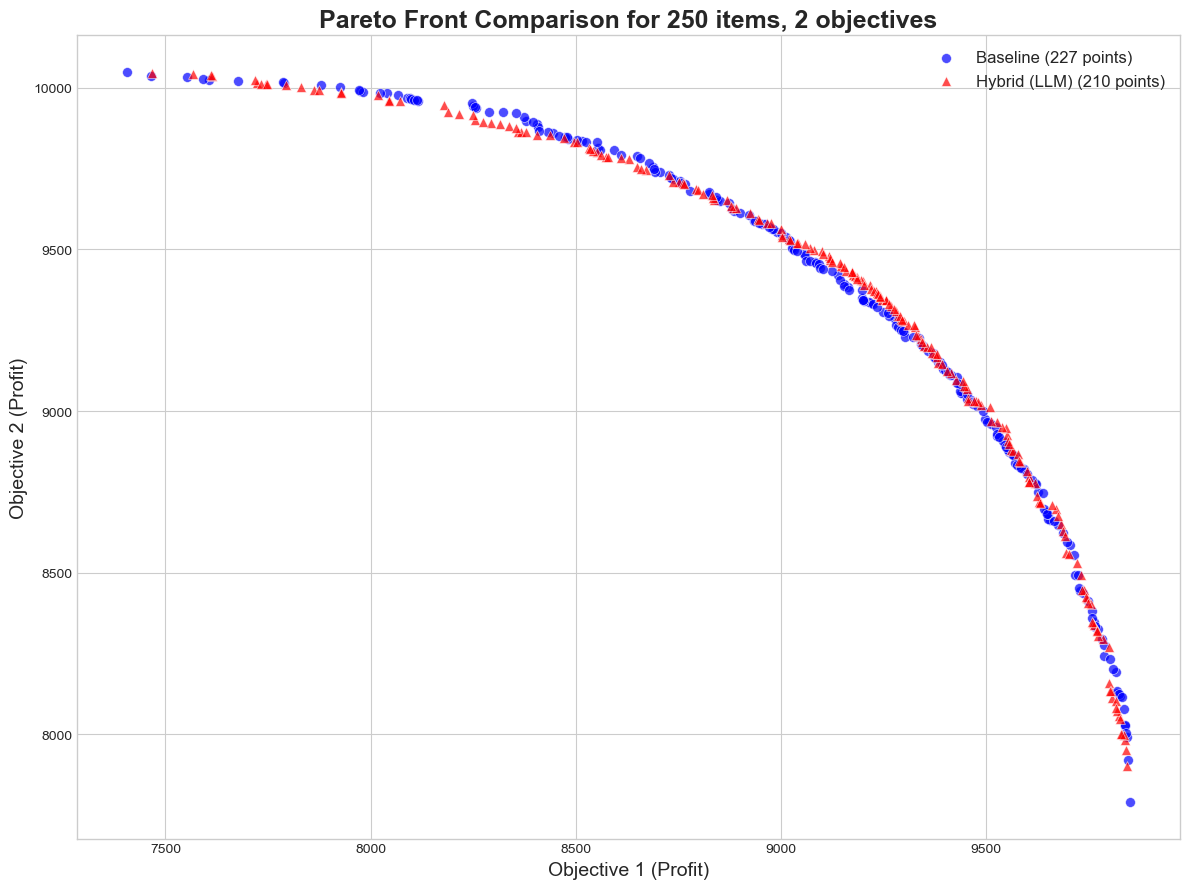

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- Helper Functions (same as before) ---
def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extracts the non-dominated points from a list of points."""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def load_and_parse_results(filename):
    """Loads a results file and parses it into a list of points."""
    points = []
    try:
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line:  # Skip empty lines
                    try:
                        # Split the line by whitespace and convert to float
                        point = [float(x) for x in line.split()]
                        if len(point) == 2: # Ensure it's a 2-objective point
                            points.append(point)
                    except ValueError:
                        print(f"Warning: Could not parse line: '{line}' in {filename}")
    except FileNotFoundError:
        print(f"Error: File not found at {filename}")
        return None
    return points

def plot_pareto_comparison(baseline_file, hybrid_file, instance_name="250.2"):
    """
    Generates a comparison plot of the Pareto fronts from two result files.
    """
    print(f"📊 Generating visualization for {instance_name}...")

    # 1. Load the raw data from both files
    baseline_points = load_and_parse_results(baseline_file)
    hybrid_points = load_and_parse_results(hybrid_file)

    if baseline_points is None or hybrid_points is None:
        print("❌ Cannot generate plot due to missing or corrupt files.")
        return

    # 2. Extract the true Pareto-optimal points from each dataset
    baseline_pareto = get_true_pareto_front(baseline_points)
    hybrid_pareto = get_true_pareto_front(hybrid_points)

    # 3. Prepare data for plotting
    if not baseline_pareto or not hybrid_pareto:
        print("❌ One of the result files is empty. Cannot plot.")
        return
        
    baseline_x, baseline_y = zip(*baseline_pareto)
    hybrid_x, hybrid_y = zip(*hybrid_pareto)

    # 4. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid') # Use a clean, professional style
    plt.figure(figsize=(12, 9))

    # Plot the baseline Pareto front
    plt.scatter(baseline_x, baseline_y, 
                color='blue', 
                label=f'Baseline ({len(baseline_pareto)} points)', 
                alpha=0.7, 
                s=50, # Marker size
                edgecolors='w', # White edge for markers
                linewidth=0.5)

    # Plot the hybrid Pareto front
    plt.scatter(hybrid_x, hybrid_y, 
                color='red', 
                label=f'Hybrid (LLM) ({len(hybrid_pareto)} points)', 
                alpha=0.7, 
                s=50,
                marker='^', # Use a different marker shape
                edgecolors='w',
                linewidth=0.5)

    # 5. Add labels, title, and legend
    plt.xlabel("Objective 1 (Profit)", fontsize=14)
    plt.ylabel("Objective 2 (Profit)", fontsize=14)
    plt.title(f"Pareto Front Comparison for {instance_name}", fontsize=18, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True) # Ensure grid is on
    plt.tight_layout() # Adjust plot to ensure everything fits without overlapping

    # 6. Save and show the plot
    output_filename = f"{instance_name}_pareto_comparison.png"
    plt.savefig(output_filename, dpi=300) # Save as a high-resolution image
    print(f"✅ Plot saved as {output_filename}")
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # --- Configuration ---
    # Make sure these filenames match the ones from your experiment controller
    BASELINE_FILE = "250_2obj_BASELINE.txt"
    HYBRID_FILE = "250_2obj_HYBRID_strategic.txt"
    INSTANCE_NAME = "250 items, 2 objectives"

    # Run the visualization
    plot_pareto_comparison(BASELINE_FILE, HYBRID_FILE, INSTANCE_NAME)
